# Single-obs cross-section (Prior / Analysis / Truth)

Vertical cross-section of **DBZ** and **vertical velocity `w`** where **every pixel is an
independent single-obs analysis** taken from the sweep output.

- **Prior** and **Truth** full fields come from the prepared 3D subset (known everywhere).
- **Analysis** = the prior overlaid with each point's own single-obs analysis wherever a
  QC-passing reflectivity observation existed (`mean_a_point_*` / `hxa_mean_obs` from the sweep).

Purpose: if a coherent zone all pushes `w` the same direction even though each point was
assimilated in isolation, the behaviour is the genuine per-point correction, not multi-point
interference. The signed per-point state means (`mean_f_point_*`, `mean_a_point_*`,
`truth_point_*`) come from `compute_single_obs_metrics` in `src/da/metrics.py`.

---

**Two traps this notebook used to fall into** (fixed 2026-07-09):

1. The reference column was hardcoded to `i_c = 235`. The GUES sweep runs at **stride 2**, so
   only **even** `i` carry an observation — `i = 235` was never assimilated. The storm maximum
   on the line `j = 272, k = 7` is at `i = 236`. Cell 2 now resolves the reference column from
   the observation set and asserts it is really observed.
2. Because `loc = 0.1 km` updates only the observed cell, the **Analysis row is a 2-cell comb**:
   every odd-`i` column is untouched prior. Comparing that against a smooth `loc = 2.0 km`
   multi-obs analysis manufactures "sign changes" that are pure sampling artefact. The
   assimilated cells are now marked in the Analysis panels.

The mechanism behind the real sign flip is worked out in `S7_SignFlip_Mechanism.ipynb`.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

REPO = '/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation'
sys.path.insert(0, REPO + '/src/fortran')
from cletkf_wloc import common_da as cda

VI = {'qg': 0, 'qr': 1, 'qs': 2, 'T': 3, 'P': 4, 'u': 5, 'v': 6, 'w': 7}

# --- dataset -------------------------------------------------------------
# 'GUES'       : 558x898 domain, same prepared file as the multiobs reference
#                figure (max prior DBZ column ~ i=234, j=272).
# 'SINGLECONF' : 307x451 domain (WS_tune 1800 subset).
DATASET = 'GUES'
_DATASETS = {
    'GUES': (
        REPO + '/data/WS_singleobs_xsec_1800_GUES/WS_singleobs_xsec_1800_GUES_sweep_Ne059_tm00.npz',
        REPO + '/data/3D_subsets_20240319_GUES_20240319180000/subset_20240319180000.npz'),
    'SINGLECONF': (
        REPO + '/data/WS_singleobs_xsec_1800/WS_singleobs_xsec_1800_sweep_Ne059_tm00.npz',
        REPO + '/data/3D_subsets_20240319_GUES_SINGLECONF_20240319180000/subset_20240319180000.npz'),
}
SWEEP, SUBSET = _DATASETS[DATASET]

R0 = 5.0                                 # obs.obs_error_var from the driving config

# --- display options -----------------------------------------------------
TM     = 0
METHOD, NTEMP, ALPHA = 'TEnKF', 1, 1.0   # analysis combo to display
WIN_KM = 40.0                            # +/- horizontal window

# Reference column. -1 => pick automatically (highest prior DBZ among the allowed rows).
# The GUES sweep runs with stride 2, so ONLY EVEN i and j carry an observation. Pinning the
# reference to an odd i (e.g. the old hardcoded i_c = 235) points it at a column that was
# never assimilated, whose "analysis" is just the prior. Cell 2 now validates the choice
# against the actual observation set instead of trusting it.
I_C = -1
J0  = 272
K_C = 7

def calc_dbz_ens(state):
    """Reflectivity for state (...,Ne,nvar) -> (...,Ne), floored at 0 dBZ."""
    ref = cda.calc_ref_ens(
        state[..., VI['qr']].astype(np.float64),
        state[..., VI['qs']].astype(np.float64),
        state[..., VI['qg']].astype(np.float64),
        state[..., VI['T']].astype(np.float64),
        state[..., VI['P']].astype(np.float64),
        min_dbz=0.0)
    return np.maximum(ref, 0.0)

In [2]:
# --- sweep rows for the chosen combo, and the storm column ----------------
d = np.load(SWEEP, allow_pickle=True)
if METHOD in ('AOEI', 'LETKF'):
    m = d['method'].astype(str) == METHOD
else:
    m = ((d['method'].astype(str) == METHOD) & (d['ntemp'] == NTEMP)
         & (np.abs(d['alpha_s'] - ALPHA) < 1e-6))
assert m.any(), 'no rows for requested combo'

ii, jj, kk = d['i'][m], d['j'][m], d['k'][m]
hxf, hxa, yoc = d['hxf_mean_obs'][m], d['hxa_mean_obs'][m], d['yo_clean'][m]
wa_pt = d['mean_a_point_w'][m]

stride_i = int(np.diff(np.unique(ii)).min())
stride_j = int(np.diff(np.unique(jj)).min())
print(f'sweep observes {len(ii)} points; stride_i={stride_i}, stride_j={stride_j}')

# Resolve the reference column, honouring only the axes that were pinned.
cand = np.ones(ii.shape, bool)
if J0 >= 0:
    cand &= jj == J0
if K_C >= 0:
    cand &= kk == K_C
if I_C >= 0:
    cand &= ii == I_C
assert cand.any(), (
    f'no observation at i={I_C}, j={J0}, k={K_C}. '
    f'With stride_i={stride_i} only i % {stride_i} == 0 are observed.')

c = int(np.flatnonzero(cand)[np.argmax(hxf[cand])])
i_c, j0, k_c = int(ii[c]), int(jj[c]), int(kk[c])

# Guard the old failure mode explicitly: the previous version of this notebook hardcoded
# i_c = 235, which is ODD and therefore never assimilated at stride 2. Its column in the
# Analysis panel was pure prior, and comparing it against the smooth loc=2.0 multi-obs
# analysis manufactured "sign changes" that were pure sampling artefact.
obs_ijk = set(zip(ii.tolist(), jj.tolist(), kk.tolist()))
assert (i_c, j0, k_c) in obs_ijk, f'reference column ({i_c},{j0},{k_c}) is not an obs point'

on_line = np.sort(ii[(jj == j0) & (kk == k_c)])
print(f'ref column: i={i_c} j={j0} k={k_c}  prior_DBZ={hxf[c]:.1f}  obs={yoc[c]:.1f} dBZ')
print(f'observed i on the line j={j0}, k={k_c}: {on_line[:4].tolist()} ... {on_line[-2:].tolist()}'
      f'  (all even; i=235 is NOT among them)')

sweep observes 750931 points; stride_i=2, stride_j=2
ref column: i=236 j=272 k=7  prior_DBZ=43.5  obs=44.8 dBZ
observed i on the line j=272, k=7: [136, 138, 210, 212] ... [554, 556]  (all even; i=235 is NOT among them)


In [3]:
# --- full prior/truth fields on the j0 slice from the subset --------------
sub = np.load(SUBSET)
ens = sub['state_ensemble']              # (nx,ny,nz,Ne_tot,nvar)
pos = sub['pos_km']
Ne_tot = ens.shape[3]
others = [e for e in range(Ne_tot) if e != TM]

# advanced indexing on axis 3 moves that axis to front -> restore with moveaxis
sl_prior = np.moveaxis(ens[:, j0, :, others, :], 0, 2)   # (nx,nz,Ne,nvar)
prior_mean = sl_prior.mean(axis=2)                       # (nx,nz,nvar)
truth_sl = ens[:, j0, :, TM, :]                          # (nx,nz,nvar)

w_prior, w_truth = prior_mean[..., VI['w']], truth_sl[..., VI['w']]
dbz_prior = calc_dbz_ens(sl_prior[:, None, :, :, :])[:, 0].mean(axis=2)      # (nx,nz)
dbz_truth = calc_dbz_ens(truth_sl[:, None, :, None, :])[:, 0, :, 0]          # (nx,nz)

X = pos[:, j0, :, 0]; Z = pos[:, j0, :, 2]
x0 = float(pos[i_c, j0, k_c, 0]); z0 = float(pos[i_c, j0, k_c, 2])
Xd = X - x0

# --- analysis = prior overlaid with per-point single-obs analysis ---------
w_anl, dbz_anl = w_prior.copy(), dbz_prior.copy()
sel = jj == j0
for i_, k_, w_, dz_ in zip(ii[sel], kk[sel], wa_pt[sel], hxa[sel]):
    w_anl[i_, k_] = w_
    dbz_anl[i_, k_] = dz_
print(f'obs points on slice j={j0}: {int(sel.sum())}')

obs points on slice j=272: 1783


window has 41 i-columns; only 19 carry an observation (46%) -> the Analysis row is a comb, not a smooth field


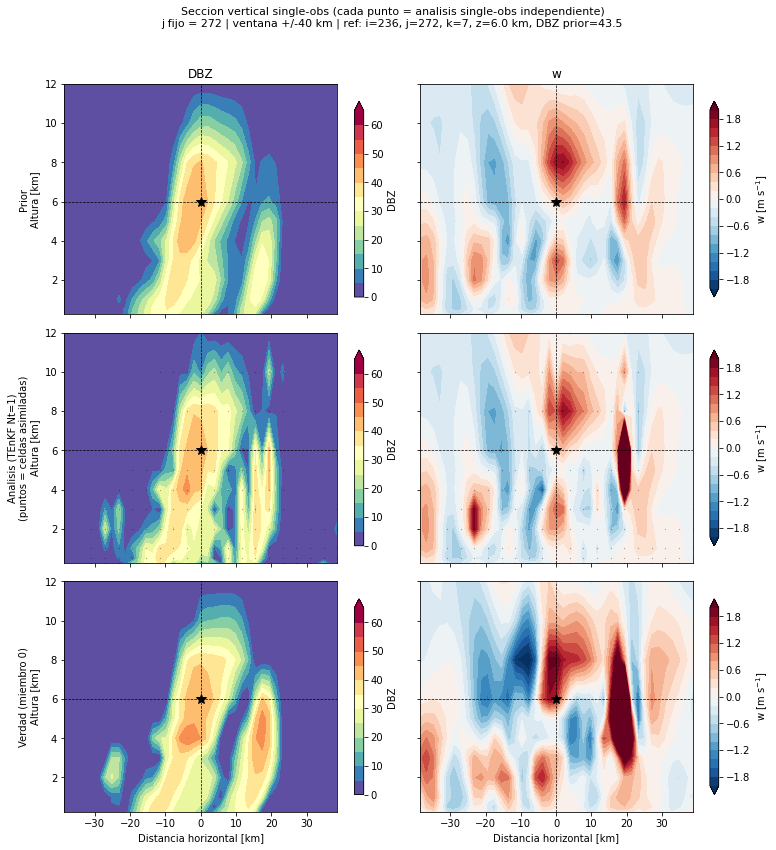

In [4]:
# --- plot -----------------------------------------------------------------
col_ok = np.abs(Xd[:, 0]) <= WIN_KM
xi = np.where(col_ok)[0]
cut = lambda F: F[xi, :]
Xw, Zw = cut(Xd), cut(Z)

dbz_lvls = np.arange(0, 66, 5)
dbz_norm = BoundaryNorm(dbz_lvls, plt.cm.Spectral_r.N)
w_lvls = np.linspace(-2.0, 2.0, 21)

fig, ax = plt.subplots(3, 2, figsize=(11, 12), sharex=True, sharey=True)
rows = [('Prior', dbz_prior, w_prior),
        (f'Analisis ({METHOD} Nt={NTEMP})', dbz_anl, w_anl),
        (f'Verdad (miembro {TM})', dbz_truth, w_truth)]
for r, (label, dbzF, wF) in enumerate(rows):
    cf0 = ax[r, 0].contourf(Xw, Zw, cut(dbzF), levels=dbz_lvls, norm=dbz_norm,
                            cmap='Spectral_r', extend='max')
    cf1 = ax[r, 1].contourf(Xw, Zw, cut(wF), levels=w_lvls, cmap='RdBu_r', extend='both')
    ax[r, 0].set_ylabel(f'{label}\nAltura [km]')
    for cc, cf, ttl in ((0, cf0, 'DBZ'), (1, cf1, 'w [m s$^{-1}$]')):
        ax[r, cc].axhline(z0, ls='--', c='k', lw=.7)
        ax[r, cc].axvline(0, ls='--', c='k', lw=.7)
        ax[r, cc].plot(0, z0, 'k*', ms=11)
        fig.colorbar(cf, ax=ax[r, cc], shrink=.85, label=ttl)

# The Analysis row only differs from the Prior where an observation was actually assimilated.
# At stride 2 (even i only) and loc = 0.1 km (each observation updates its own cell alone),
# it is a 2-cell comb: every odd-i column is untouched prior. Mark the assimilated cells so
# the interleaving is not mistaken for physical structure.
obs_i, obs_k = ii[sel], kk[sel]
keep = np.isin(obs_i, xi)
n_cols_obs = len(np.unique(obs_i[keep]))
n_cols_win = len(xi)
for cc in (0, 1):
    ax[1, cc].scatter(Xd[obs_i[keep], obs_k[keep]], Z[obs_i[keep], obs_k[keep]],
                      s=1.5, c='k', alpha=.35, linewidths=0, zorder=5)
ax[1, 0].set_ylabel(f'{rows[1][0]}\n(puntos = celdas asimiladas)\nAltura [km]')
print(f'window has {n_cols_win} i-columns; only {n_cols_obs} carry an observation '
      f'({n_cols_obs/n_cols_win:.0%}) -> the Analysis row is a comb, not a smooth field')

ax[0, 0].set_title('DBZ'); ax[0, 1].set_title('w')
for cc in (0, 1):
    ax[2, cc].set_xlabel('Distancia horizontal [km]')
fig.suptitle('Seccion vertical single-obs (cada punto = analisis single-obs independiente)\n'
             f'j fijo = {j0} | ventana +/-{WIN_KM:.0f} km | ref: i={i_c}, j={j0}, k={k_c}, '
             f'z={z0:.1f} km, DBZ prior={hxf[c]:.1f}', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Diagnostic: when does the single-obs analysis flip the sign of `w`?

The bare sign-flip fraction is **not** a measure of the pathology. It counts every cell where
`sign(w_a) != sign(w_f)`, which is dominated by cells whose prior `w` sits at the noise floor
and flips on rounding. Grade by magnitude instead.

The real failure is: **truth has a strong updraft, the prior has a weak updraft, the analysis
produces a strong downdraft.** For a single scalar observation `letkf_core` collapses exactly to

$$\Delta w \;=\; \frac{\mathrm{cov}(w, h)}{\mathrm{var}(h) + R}\; d_b ,\qquad d_b = y_o - \overline{H(x^f)}$$

with `cov`/`var` at `ddof=1` and `R = obs_error_var`. This is exact, not an approximation: `w`
is never clamped (only `qr/qs/qg` are), so its update is strictly linear. Consequently
`cov(w, h)` can be **inverted from the stored increment** with no ensemble read:

$$\mathrm{cov}(w,h) \;=\; \Delta w \,\frac{\mathrm{var}(h) + R}{d_b}$$

using `spread_f_obs` and `dep_b`, which the sweep already writes. Valid for `TEnKF, ntemp=1`
(which is plain LETKF, since `tempering_schedule(1, a) = [1.0]`).

bare sign-flip fraction        : 16.795%  of 750931 points
  ... with |w_f| < 0.05 m/s    : 58.7%   <- noise-floor flips, not the pathology

truth updraft & prior updraft & analysis downdraft, graded by threshold [m/s]:
  |w| > 0.25    886 points   (0.1180%)
  |w| > 0.5     124 points   (0.0165%)
  |w| > 1.0      24 points   (0.0032%)
  |w| > 2.0       1 points   (0.0001%)

at the 24 severe points:
  cov(w,h) < 0   : 100.0%      (all points: 47.6%)
  dep_b    > 0   : 100.0%      (all points: 30.6%)
  prior DBZ  hxf: median     1.693   (all:     1.518)
  obs DBZ    yo : median    41.885   (all:     0.000)
  innovation dep: median    39.725   (all:    -0.589)
  cov(w,h)      : median    -2.000   (all:     0.006)
  gain K        : median    -0.036   (all:     0.001)
  w_f  [m/s]    : median     0.038   (all:     0.010)
  w_a  [m/s]    : median    -1.214   (all:     0.004)
  w_true [m/s]  : median     3.235   (all:    -0.003)


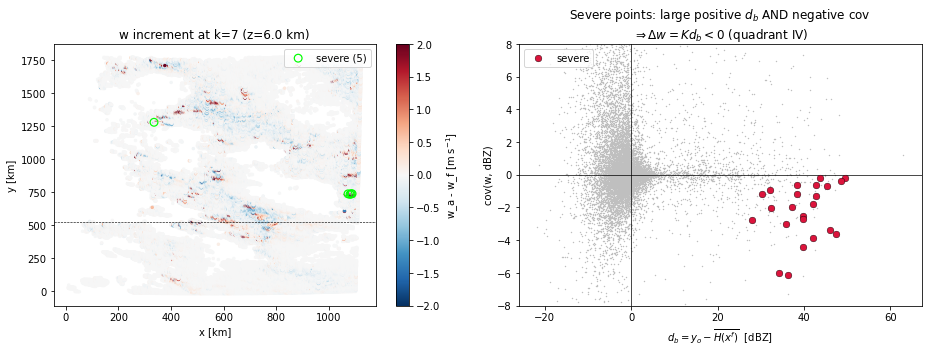

In [5]:
wf_all = d['mean_f_point_w'][m]
wa_all = d['mean_a_point_w'][m]
wt_all = d['truth_point_w'][m]
dep_b  = d['dep_b'][m]
var_h  = d['spread_f_obs'][m] ** 2
kk_all = d['k'][m]

# --- why the bare flip fraction misleads ---------------------------------
soft = (np.sign(wa_all) != np.sign(wf_all)) & (np.abs(wf_all) > 1e-6)
print(f'bare sign-flip fraction        : {np.nanmean(soft):.3%}  of {soft.size} points')
print(f'  ... with |w_f| < 0.05 m/s    : {np.nanmean(np.abs(wf_all[soft]) < 0.05):.1%}'
      '   <- noise-floor flips, not the pathology\n')

print('truth updraft & prior updraft & analysis downdraft, graded by threshold [m/s]:')
for thr in (0.25, 0.5, 1.0, 2.0):
    sev = (wt_all > thr) & (wf_all > 0) & (wa_all < -thr)
    print(f'  |w| > {thr:<4}  {int(np.nansum(sev)):>5d} points   ({np.nanmean(sev):.4%})')
BAD = (wt_all > 1.0) & (wf_all > 0) & (wa_all < -1.0)

# --- invert cov(w,h) from the exact scalar-gain identity -------------------
assert (METHOD, NTEMP) == ('TEnKF', 1), 'the closed-form inversion below assumes plain LETKF'
ok = np.abs(dep_b) > 1e-3
cov_wh = np.full(wf_all.shape, np.nan)
cov_wh[ok] = (wa_all - wf_all)[ok] * (var_h[ok] + R0) / dep_b[ok]
gain = cov_wh / (var_h + R0)

print(f'\nat the {int(BAD.sum())} severe points:')
print(f'  cov(w,h) < 0   : {np.nanmean(cov_wh[BAD] < 0):.1%}      (all points: {np.nanmean(cov_wh[ok] < 0):.1%})')
print(f'  dep_b    > 0   : {np.nanmean(dep_b[BAD] > 0):.1%}      (all points: {np.nanmean(dep_b[ok] > 0):.1%})')
for lbl, arr in (('prior DBZ  hxf', d['hxf_mean_obs'][m]), ('obs DBZ    yo ', d['yo_clean'][m]),
                 ('innovation dep', dep_b), ('cov(w,h)      ', cov_wh),
                 ('gain K        ', gain), ('w_f  [m/s]    ', wf_all),
                 ('w_a  [m/s]    ', wa_all), ('w_true [m/s]  ', wt_all)):
    print(f'  {lbl}: median {np.nanmedian(arr[BAD]):>9.3f}   (all: {np.nanmedian(arr[ok]):>9.3f})')

# --- panels ---------------------------------------------------------------
fig, axm = plt.subplots(1, 2, figsize=(13, 5))

lev = kk_all == k_c
sc = axm[0].scatter(d['x_km'][m][lev], d['y_km'][m][lev], c=(wa_all - wf_all)[lev],
                    cmap='RdBu_r', vmin=-2, vmax=2, s=6)
bl = BAD & lev
axm[0].scatter(d['x_km'][m][bl], d['y_km'][m][bl], s=60, facecolors='none',
               edgecolors='lime', linewidths=1.2, label=f'severe ({int(bl.sum())})')
axm[0].axhline(pos[i_c, j0, k_c, 1], ls='--', c='k', lw=.6)
axm[0].set_xlabel('x [km]'); axm[0].set_ylabel('y [km]'); axm[0].legend(loc='upper right')
axm[0].set_title(f'w increment at k={k_c} (z={z0:.1f} km)')
fig.colorbar(sc, ax=axm[0], label='w_a - w_f [m s$^{-1}$]')

s = ok & np.isfinite(cov_wh)
sub_i = np.flatnonzero(s)[::37]                       # thin for legibility
axm[1].scatter(dep_b[sub_i], cov_wh[sub_i], s=2, c='0.75', linewidths=0)
axm[1].scatter(dep_b[BAD], cov_wh[BAD], s=45, c='crimson', edgecolors='k',
               linewidths=.4, label='severe', zorder=4)
axm[1].axhline(0, c='k', lw=.7); axm[1].axvline(0, c='k', lw=.7)
axm[1].set_xlabel('$d_b = y_o - \\overline{H(x^f)}$  [dBZ]')
axm[1].set_ylabel('cov(w, dBZ)')
axm[1].set_ylim(-8, 8); axm[1].legend(loc='upper left')
axm[1].set_title('Severe points: large positive $d_b$ AND negative cov\n'
                 '$\\Rightarrow \\Delta w = K d_b < 0$ (quadrant IV)')
fig.tight_layout()
plt.show()